# Логистическая регрессия: бинарная классификация качества вина

Датасет: **WineQT.csv** — красное вино (1143 записи, 12 признаков).  
Бинарная классификация: `quality >= 7` → хорошее вино (1), иначе обычное (0).

**Задачи:**
1. Предобработка и EDA
2. Логистическая регрессия + кросс-валидация
3. Confusion matrix, classification report, AUC-ROC
4. Оптимальный порог
5. Precision vs Recall
6. Регуляризация (L1, L2, ElasticNet)
7. **Бонус:** мультиклассовая классификация (3 класса)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100

In [4]:
df = pd.read_csv('../WineQT.csv')
df = df.drop('Id', axis=1)

print(f'Размер: {df.shape}')
print(f'\nРаспределение quality:\n{df["quality"].value_counts().sort_index()}')
df.head()

Размер: (1143, 12)

Распределение quality:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
# Бинарная целевая переменная: quality >= 7 → 1 (хорошее), иначе 0 (обычное)
df['target'] = (df['quality'] >= 7).astype(int)
df = df.drop('quality', axis=1)

print(f'Классы: 0 = обычное, 1 = хорошее')
print(f'Распределение:\n{df["target"].value_counts()}')
print(f'\nДоля хорошего вина: {df["target"].mean():.1%}')

Классы: 0 = обычное, 1 = хорошее
Распределение:
target
0    984
1    159
Name: count, dtype: int64

Доля хорошего вина: 13.9%


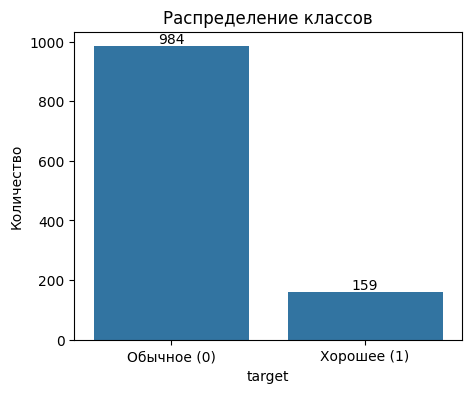

In [7]:
# Распределение классов
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='target', data=df)
ax.set_xticklabels(['Обычное (0)', 'Хорошее (1)'])
plt.title('Распределение классов')
plt.ylabel('Количество')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
               ha='center', va='bottom')
plt.show()

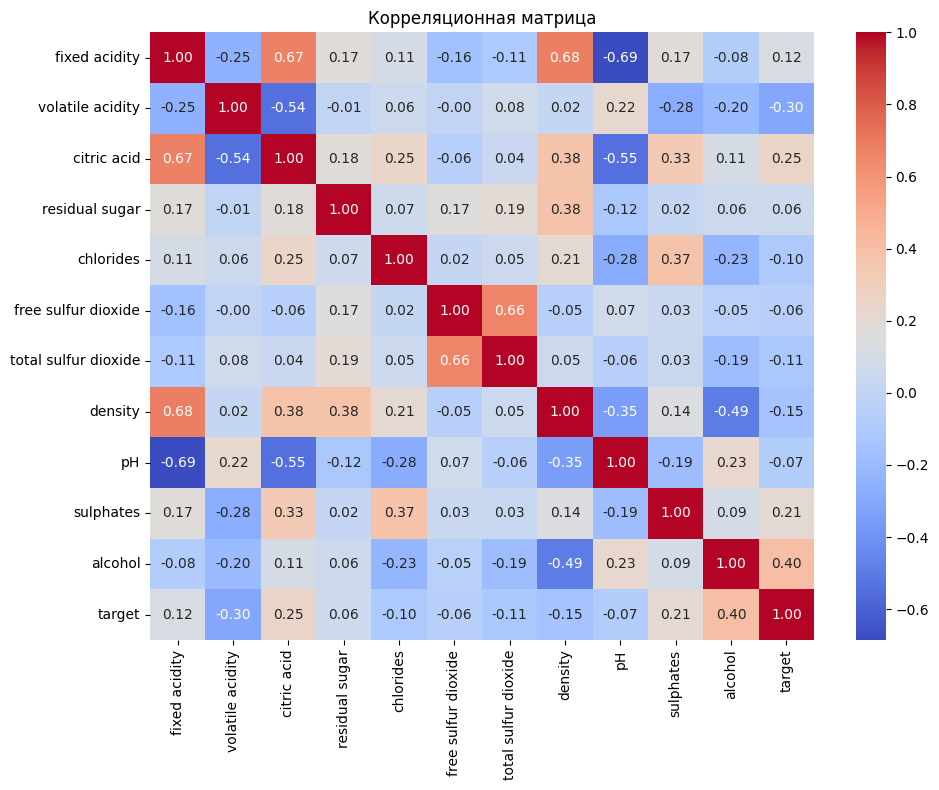

In [8]:
# Корреляционная матрица
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

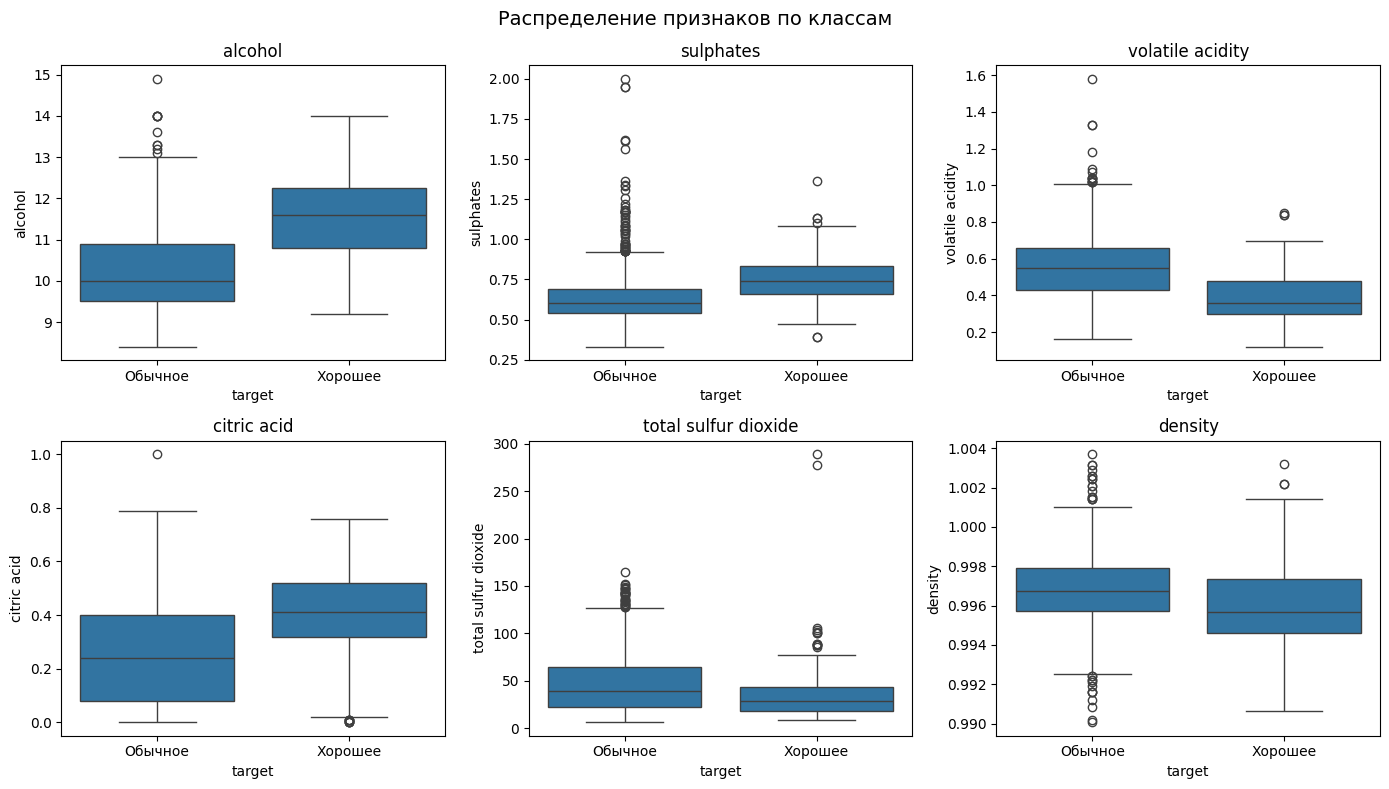

In [9]:
# Boxplots ключевых признаков по классам
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['alcohol', 'sulphates', 'volatile acidity', 'citric acid', 'total sulfur dioxide', 'density']

for ax, feat in zip(axes.flat, features):
    sns.boxplot(x='target', y=feat, data=df, ax=ax)
    ax.set_xticklabels(['Обычное', 'Хорошее'])
    ax.set_title(feat)

plt.suptitle('Распределение признаков по классам', fontsize=14)
plt.tight_layout()
plt.show()

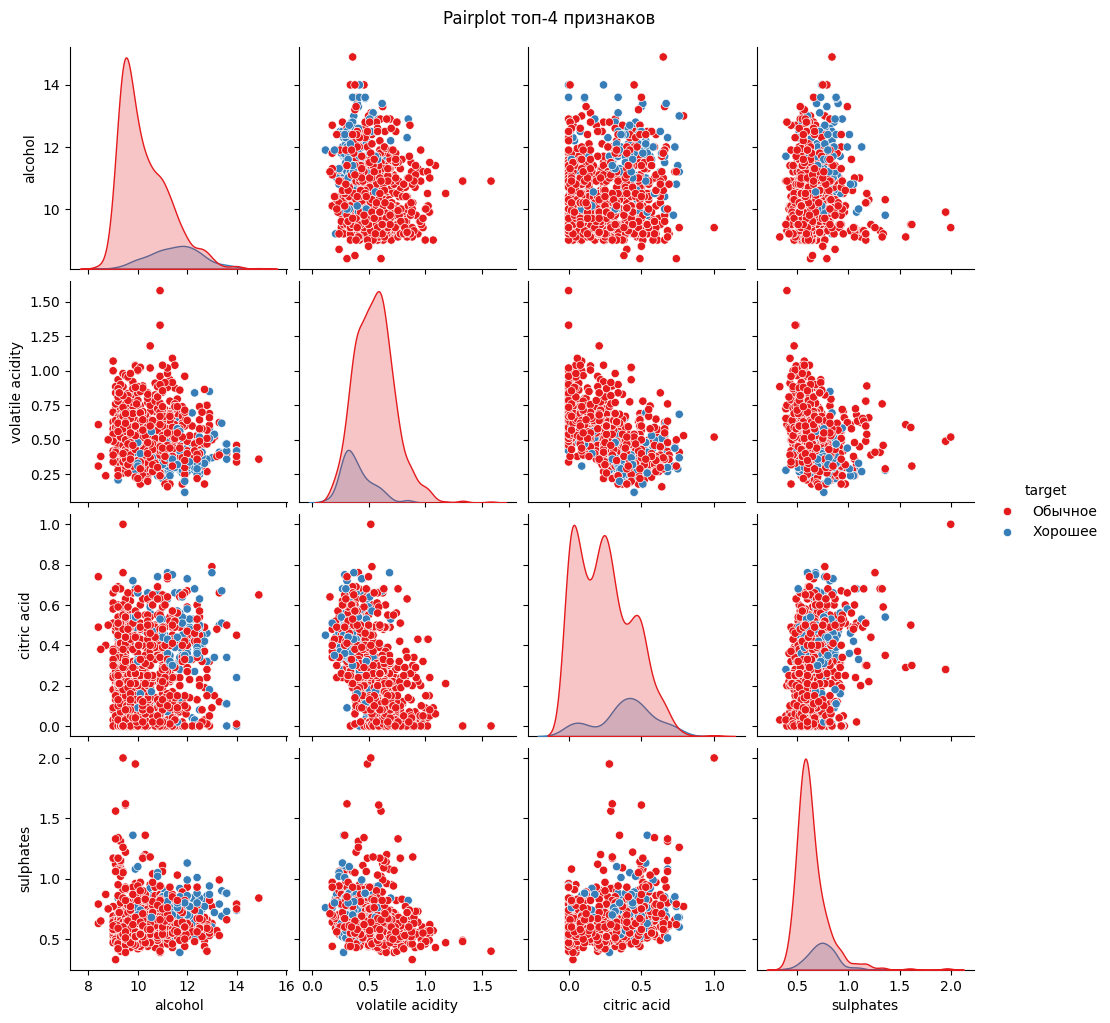

In [10]:
# Pairplot топ-4 признаков по корреляции с target
corr_with_target = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
top4 = corr_with_target.head(4).index.tolist()

plot_df = df[top4 + ['target']].copy()
plot_df['target'] = plot_df['target'].map({0: 'Обычное', 1: 'Хорошее'})

sns.pairplot(plot_df, hue='target', diag_kind='kde', palette='Set1')
plt.suptitle('Pairplot топ-4 признаков', y=1.02)
plt.show()

In [11]:
# Проверка пропусков
print(f'Пропуски: {df.isnull().sum().sum()}')

# Train/test split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'Классы в train: {y_train.value_counts().to_dict()}')
print(f'Классы в test:  {y_test.value_counts().to_dict()}')

Пропуски: 0
Train: 914, Test: 229
Классы в train: {0: 787, 1: 127}
Классы в test:  {0: 197, 1: 32}


In [12]:
# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Стандартизация выполнена.')

Стандартизация выполнена.


In [13]:
# Обучение модели
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

# Кросс-валидация (5-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print(f'CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'По фолдам: {[f"{s:.4f}" for s in cv_scores]}')

Accuracy: 0.8646
CV Accuracy: 0.8764 (+/- 0.0301)
По фолдам: ['0.9126', '0.8525', '0.8634', '0.8415', '0.9121']


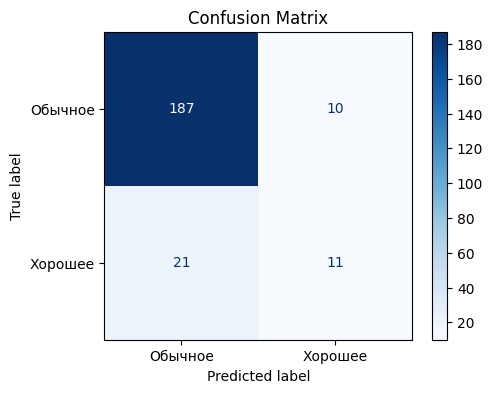

TN=187, FP=10, FN=21, TP=11


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Обычное', 'Хорошее']).plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix')
plt.show()

print(f'TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}')

In [15]:
# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Обычное', 'Хорошее']))

Classification Report:
              precision    recall  f1-score   support

     Обычное       0.90      0.95      0.92       197
     Хорошее       0.52      0.34      0.42        32

    accuracy                           0.86       229
   macro avg       0.71      0.65      0.67       229
weighted avg       0.85      0.86      0.85       229



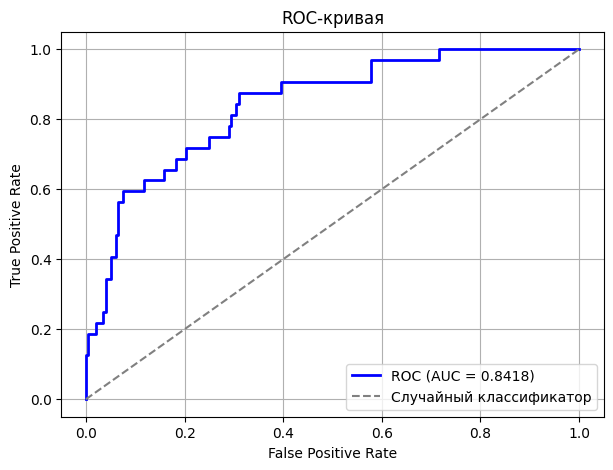

AUC-ROC: 0.8418


In [16]:
# ROC-кривая и AUC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True)
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}')

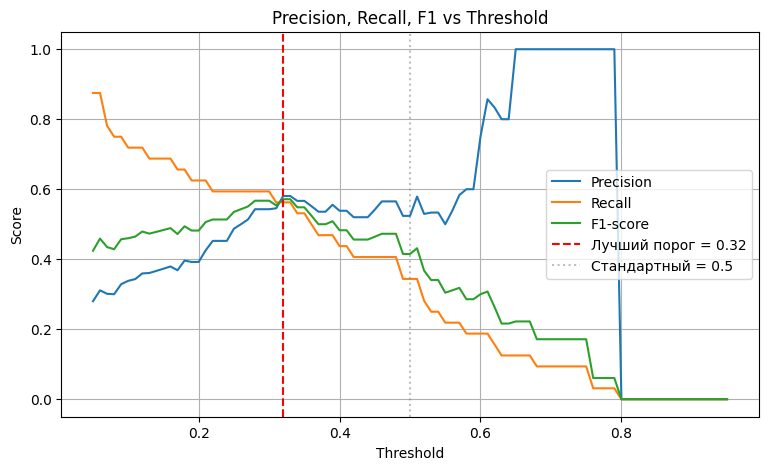

Лучший порог по F1: 0.32
F1=0.5714, Precision=0.5806, Recall=0.5625


In [17]:
# Перебор порогов
thresholds = np.arange(0.05, 0.96, 0.01)
f1_scores_list = []
precisions_list = []
recalls_list = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    precisions_list.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls_list.append(recall_score(y_test, y_pred_t))
    f1_scores_list.append(f1_score(y_test, y_pred_t, zero_division=0))

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions_list, label='Precision')
plt.plot(thresholds, recalls_list, label='Recall')
plt.plot(thresholds, f1_scores_list, label='F1-score')

best_idx = np.argmax(f1_scores_list)
best_t = thresholds[best_idx]
plt.axvline(x=best_t, color='red', linestyle='--', label=f'Лучший порог = {best_t:.2f}')
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Стандартный = 0.5')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

print(f'Лучший порог по F1: {best_t:.2f}')
print(f'F1={f1_scores_list[best_idx]:.4f}, Precision={precisions_list[best_idx]:.4f}, Recall={recalls_list[best_idx]:.4f}')

In [18]:
# Демонстрация влияния порога на precision/recall
print('=== Влияние порога на метрики класса "Хорошее" (1) ===\n')
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t)
    acc = accuracy_score(y_test, y_pred_t)
    print(f'Threshold={t:.1f}: Precision={prec:.4f}, Recall={rec:.4f}, Accuracy={acc:.4f}')

=== Влияние порога на метрики класса "Хорошее" (1) ===

Threshold=0.3: Precision=0.5429, Recall=0.5938, Accuracy=0.8734
Threshold=0.4: Precision=0.5385, Recall=0.4375, Accuracy=0.8690
Threshold=0.5: Precision=0.5238, Recall=0.3438, Accuracy=0.8646
Threshold=0.6: Precision=0.7500, Recall=0.1875, Accuracy=0.8777
Threshold=0.7: Precision=1.0000, Recall=0.0938, Accuracy=0.8734


## 8. Регуляризация — сравнение L1, L2, ElasticNet

In [19]:
# Сравнение типов регуляризации с подбором C
penalties = {
    'L2 (Ridge)': {'penalty': 'l2', 'solver': 'lbfgs'},
    'L1 (Lasso)': {'penalty': 'l1', 'solver': 'saga'},
    'ElasticNet':  {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5},
}

C_values = np.logspace(-3, 3, 15)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_reg = {}
for name, params in penalties.items():
    cv_means = []
    for C in C_values:
        model = LogisticRegression(C=C, random_state=42, max_iter=5000, **params)
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
        cv_means.append(scores.mean())
    results_reg[name] = cv_means
    best_idx = np.argmax(cv_means)
    print(f'{name}: лучший C={C_values[best_idx]:.4f}, accuracy={cv_means[best_idx]:.4f}')

L2 (Ridge): лучший C=0.1389, accuracy=0.8797
L1 (Lasso): лучший C=1.0000, accuracy=0.8786
ElasticNet: лучший C=0.3728, accuracy=0.8797


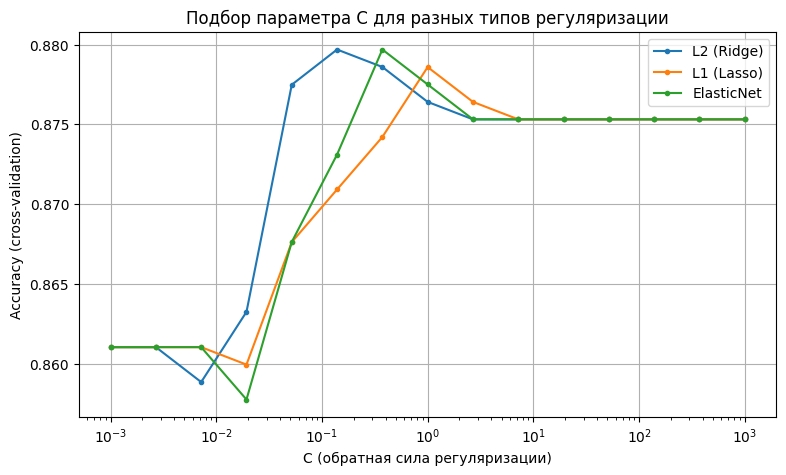

In [20]:
# График: C vs Accuracy
plt.figure(figsize=(9, 5))
for name, cv_means in results_reg.items():
    plt.plot(C_values, cv_means, marker='.', label=name)

plt.xscale('log')
plt.xlabel('C (обратная сила регуляризации)')
plt.ylabel('Accuracy (cross-validation)')
plt.title('Подбор параметра C для разных типов регуляризации')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Сравнительная таблица лучших моделей
comparison = []
feature_names = X.columns.tolist()

for name, params in penalties.items():
    cv_means = results_reg[name]
    best_idx = np.argmax(cv_means)
    best_C = C_values[best_idx]

    model = LogisticRegression(C=best_C, random_state=42, max_iter=5000, **params)
    model.fit(X_train_scaled, y_train)
    y_pred_r = model.predict(X_test_scaled)
    y_prob_r = model.predict_proba(X_test_scaled)[:, 1]

    fpr_r, tpr_r, _ = roc_curve(y_test, y_prob_r)

    comparison.append({
        'Модель': name,
        'C': round(best_C, 4),
        'Accuracy': round(accuracy_score(y_test, y_pred_r), 4),
        'Precision': round(precision_score(y_test, y_pred_r, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred_r), 4),
        'F1': round(f1_score(y_test, y_pred_r, zero_division=0), 4),
        'AUC-ROC': round(auc(fpr_r, tpr_r), 4),
        'Ненулевых коэф.': int(np.sum(model.coef_[0] != 0)),
    })

pd.DataFrame(comparison)

,Модель,C,Accuracy,Precision,Recall,F1,AUC-ROC,Ненулевых коэф.
0,L2 (Ridge),0.1389,0.8777,0.6111,0.3438,0.4400,0.8428,11
1,L1 (Lasso),1.0000,0.8690,0.5500,0.3438,0.4231,0.8414,11
2,ElasticNet,0.3728,0.8690,0.5500,0.3438,0.4231,0.8415,11
